# Practice Lab Neural Network 1
# Neural Network Implementation from Scratch
---
**MIT Academy of Engineering, Alandi, Pune**

**Department of CSE (AI/ML) | Course: Generative AI Lab**

---

**Name of Student:** Sneha Chaurasia

**PRN:** 202401110046

**Class:** T.Y. BTech

**Batch:** A3

**Date of Submission:** 16/08/2026

---

## 1. Objective

Implement a simple **feedforward neural network from scratch** in Python — without using any in-built deep learning libraries (no TensorFlow, PyTorch, or Keras).

This notebook builds and trains a neural network manually, covering:
- **Forward pass** — computing weighted sums and applying activation functions layer by layer
- **Backpropagation** — deriving and applying gradients of the loss w.r.t. every weight and bias
- **Training via gradient descent** — iteratively updating parameters to minimize the loss

Only `numpy`, `pandas`, and `matplotlib` are used for computation and visualization. `scikit-learn` is used **only** for the train/test split utility and evaluation metrics (confusion matrix) — not for any model building.

## 2. Problem Definition

**Dataset:** [Iris Dataset](https://archive.ics.uci.edu/dataset/53/iris) (UCI Machine Learning Repository / Fisher, 1936)

- 150 samples total, 50 from each of 3 species of Iris flower
- 4 input features (all real-valued, in cm):
  1. Sepal length
  2. Sepal width
  3. Petal length
  4. Petal width
- 3 target classes: *Iris-setosa*, *Iris-versicolor*, *Iris-virginica*

**Task:** Multi-class classification — predict the species of an Iris flower from its 4 measurements.

The Iris dataset is small, clean, and well-separated, which makes it ideal for verifying that a from-scratch backpropagation implementation is mathematically correct before scaling to larger data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# sklearn is used ONLY for data splitting and evaluation metrics, NOT for building or training the neural network itself
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

# Reproducibility
np.random.seed(42)

%matplotlib inline

## 3. Methodology — Network Architecture

We use a simple **3-layer feedforward neural network**:

| Layer        | Neurons | Activation |
|--------------|---------|------------|
| Input        | 4       | —          |
| Hidden       | 8       | ReLU       |
| Output       | 3       | Softmax    |

- **Hidden layer activation — ReLU:** `f(x) = max(0, x)`. Chosen for fast, stable gradients and to avoid vanishing gradients in the hidden layer.
- **Output layer activation — Softmax:** converts raw output scores (logits) into a probability distribution across the 3 classes, so the highest-probability class is the prediction.
- **Loss function — Categorical Cross-Entropy:** standard loss for multi-class classification, paired naturally with softmax output.
- **Optimizer — Batch Gradient Descent:** weights and biases updated using the full training set gradient at each epoch.
- **Learning rate:** 0.1
- **Number of epochs:** 1000

In [2]:
# Load the Iris dataset (uploaded alongside this notebook as 'iris.data')
columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
df = pd.read_csv('iris.data', header=None, names=columns)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
# Check for missing values / class balance
print(df['species'].value_counts())
print("\nMissing values per column:\n", df.isnull().sum())

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Missing values per column:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [4]:
# Separate features (X) and labels (y)
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values
y_raw = df['species'].values

# Encode class labels as integers: setosa=0, versicolor=1, virginica=2
class_names = np.unique(y_raw)
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
y_idx = np.array([class_to_idx[label] for label in y_raw])

print("Classes:", class_to_idx)

Classes: {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}


In [5]:
# Feature normalization (standardization): mean=0, std=1
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_norm = (X - X_mean) / X_std

# One-hot encode the labels for cross-entropy loss with softmax output
def one_hot_encode(y, num_classes):
    one_hot = np.zeros((y.shape[0], num_classes))
    one_hot[np.arange(y.shape[0]), y] = 1
    return one_hot

num_classes = len(class_names)
y_onehot = one_hot_encode(y_idx, num_classes)

# Train/test split (80/20), stratified so class balance is preserved
X_train, X_test, y_train, y_test, y_train_idx, y_test_idx = train_test_split(
    X_norm, y_onehot, y_idx, test_size=0.2, random_state=42, stratify=y_idx
)

print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (120, 4) (120, 3)
Test set: (30, 4) (30, 3)


## Part A: Forward Pass

The forward pass computes predictions layer by layer:

*Z1 = XW1 + b1*

*A1 = ReLU(Z1)*

*Z2 = A1W2 + b2*

*A2 = Softmax(Z2)*


Weights are initialized with **He initialization** (suited for ReLU) to keep gradients well-scaled at the start of training.

In [13]:
def init_params(input_size, hidden_size, output_size):
    """He initialization for weights, zeros for biases."""
    W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
    b2 = np.zeros((1, output_size))
    return {'W1': W1, 'b1': b1, 'W2': W2, 'b2': b2}

def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return (Z > 0).astype(float)

def softmax(Z):
    # Subtract max per row for numerical stability
    Z_shifted = Z - np.max(Z, axis=1, keepdims=True)
    exp_Z = np.exp(Z_shifted)
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

def forward_pass(X, params):
    """Computes activations for one forward pass through the network."""
    Z1 = X @ params['W1'] + params['b1']
    A1 = relu(Z1)
    Z2 = A1 @ params['W2'] + params['b2']
    A2 = softmax(Z2)

    cache = {'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A2': A2}
    return A2, cache
# Test forward pass
params = init_params(4, 8, 3)
y_pred, cache = forward_pass(X_train, params)
print("Prediction shape:", y_pred.shape)
print("Cache keys:", cache.keys())
print("First prediction probabilities:", y_pred[0])

Prediction shape: (120, 3)
Cache keys: dict_keys(['Z1', 'A1', 'Z2', 'A2'])
First prediction probabilities: [0.2580324  0.06490356 0.67706403]


## Part B: Backpropagation

**Loss function — Categorical Cross-Entropy:**

$$L = -\frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{K} y_{ik} \log(\hat{y}_{ik})$$

**Backpropagation** applies the chain rule to compute how much each weight and bias contributed to the error, working backward from the output layer to the input layer:

**dZ2 = A2 - Y**

Then:

**dW2 = A1ᵀ dZ2 / m**

**db2 = sum(dZ2) / m**

The hidden-layer gradient is:

**dA1 = dZ2 W2ᵀ**

**dZ1 = dA1 × ReLU'(Z1)**

Then:

**dW1 = Xᵀ dZ1 / m**

**db1 = sum(dZ1) / m**

where `m` is the number of training examples.
Note: `dZ2 = A2 - Y` is the simplified combined derivative of softmax + cross-entropy, which is why we pair these two functions.

In [14]:
def compute_loss(y_true, y_pred):
    """Categorical cross-entropy loss with a small epsilon to avoid log(0)."""
    m = y_true.shape[0]
    epsilon = 1e-12
    y_pred_clipped = np.clip(y_pred, epsilon, 1 - epsilon)
    loss = -np.sum(y_true * np.log(y_pred_clipped)) / m
    return loss

def backward_pass(X, y_true, params, cache):
    """Computes gradients of the loss w.r.t. all weights and biases."""
    m = X.shape[0]
    A1, A2 = cache['A1'], cache['A2']
    Z1 = cache['Z1']

    # Output layer gradients (softmax + cross-entropy combined derivative)
    dZ2 = A2 - y_true
    dW2 = (A1.T @ dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    # Hidden layer gradients
    dA1 = dZ2 @ params['W2'].T
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = (X.T @ dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    grads = {'dW1': dW1, 'db1': db1, 'dW2': dW2, 'db2': db2}
    return grads

def update_params(params, grads, learning_rate):
    """Gradient descent parameter update step."""
    params['W1'] -= learning_rate * grads['dW1']
    params['b1'] -= learning_rate * grads['db1']
    params['W2'] -= learning_rate * grads['dW2']
    params['b2'] -= learning_rate * grads['db2']
    return params

## Part C: Gradient Secent training Loop

We train using **batch gradient descent**: each epoch performs one full forward pass, one full backward pass, and one parameter update using the entire training set.

Hyperparameters:
- Hidden neurons: 8
- Learning rate: 0.1
- Epochs: 1000

In [15]:
# Hyperparameters
input_size = X_train.shape[1]   # 4 features
hidden_size = 8
output_size = num_classes       # 3 classes
learning_rate = 0.1
epochs = 1000

# Initialize parameters
params = init_params(input_size, hidden_size, output_size)

train_losses = []
train_accuracies = []

for epoch in range(epochs):
    # Forward pass
    y_pred, cache = forward_pass(X_train, params)

    # Compute loss
    loss = compute_loss(y_train, y_pred)
    train_losses.append(loss)

    # Backward pass
    grads = backward_pass(X_train, y_train, params, cache)

    # Update parameters
    params = update_params(params, grads, learning_rate)

    # Track training accuracy
    preds = np.argmax(y_pred, axis=1)
    acc = np.mean(preds == y_train_idx)
    train_accuracies.append(acc)

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs}  |  Loss: {loss:.4f}  |  Train Accuracy: {acc:.4f}")

Epoch 100/1000  |  Loss: 0.2262  |  Train Accuracy: 0.9250
Epoch 200/1000  |  Loss: 0.1238  |  Train Accuracy: 0.9667
Epoch 300/1000  |  Loss: 0.0876  |  Train Accuracy: 0.9750
Epoch 400/1000  |  Loss: 0.0712  |  Train Accuracy: 0.9750
Epoch 500/1000  |  Loss: 0.0625  |  Train Accuracy: 0.9750
Epoch 600/1000  |  Loss: 0.0571  |  Train Accuracy: 0.9750
Epoch 700/1000  |  Loss: 0.0536  |  Train Accuracy: 0.9750
Epoch 800/1000  |  Loss: 0.0513  |  Train Accuracy: 0.9750
Epoch 900/1000  |  Loss: 0.0496  |  Train Accuracy: 0.9750
Epoch 1000/1000  |  Loss: 0.0482  |  Train Accuracy: 0.9750


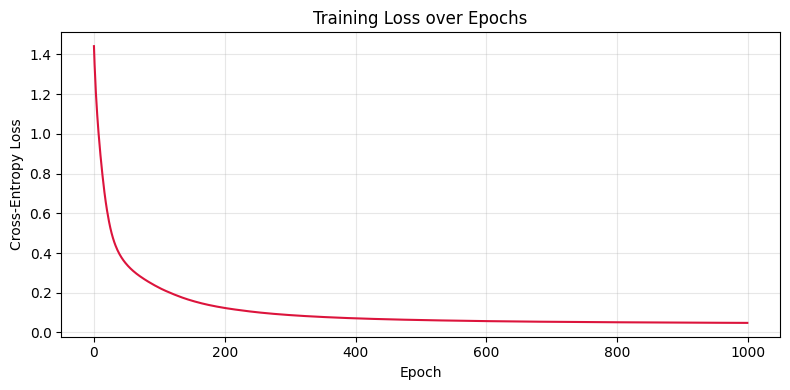

In [17]:
# Plot training loss curve
plt.figure(figsize=(8, 4))
plt.plot(train_losses, color='crimson')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()

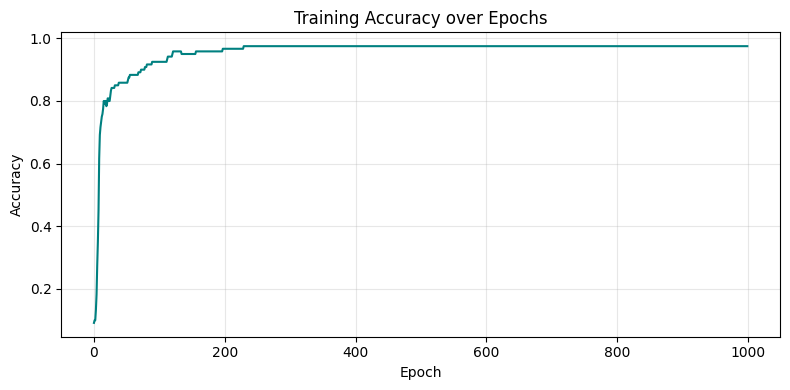

In [18]:
# Plot training accuracy curve
plt.figure(figsize=(8, 4))
plt.plot(train_accuracies, color='teal')
plt.title('Training Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('accuracy_curve.png', dpi=150)
plt.show()

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]




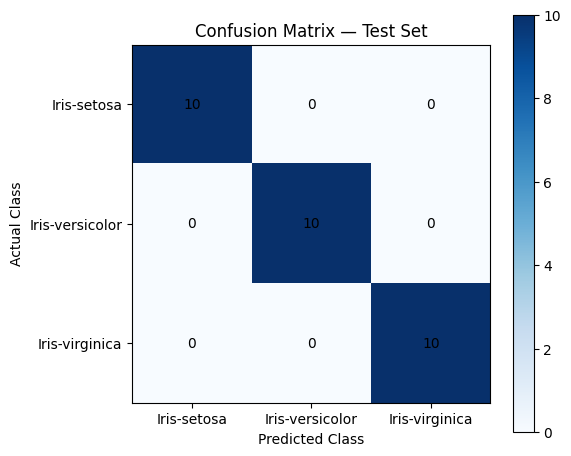

In [26]:
# Build confusion matrix manually (from scratch, no sklearn)
num_classes = 3
conf_matrix = np.zeros((num_classes, num_classes), dtype=int)

# First, get predictions for the test set (if not already done)
# This part of the code might be run before the cell that calculates y_test_pred
y_test_pred_probs, _ = forward_pass(X_test, params)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)

for actual, predicted in zip(y_test_idx, y_test_pred):
    conf_matrix[actual, predicted] += 1

print("Confusion Matrix:")
print(conf_matrix)
print("\n")
plt.figure(figsize=(6, 5))
plt.imshow(conf_matrix, cmap='Blues')
plt.title("Confusion Matrix — Test Set")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks(range(num_classes), class_names)
plt.yticks(range(num_classes), class_names)

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, conf_matrix[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## 4. Final Predictions & Results

Evaluating the trained network on the **held-out test set** (data it never saw during training).

In [22]:
# Run forward pass on test set (inference only, no parameter updates)
y_test_pred_probs, _ = forward_pass(X_test, params)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)

test_accuracy = accuracy_score(y_test_idx, y_test_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test_idx, y_test_pred, target_names=class_names))

Test Accuracy: 1.0000

Classification Report:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [25]:
# Sample predictions vs actual labels
sample_idx = np.random.choice(len(X_test), size=10, replace=False)
print(f"{'Actual':<18}{'Predicted':<18}{'Correct?'}")
print("-" * 45)
for i in sample_idx:
    actual = class_names[y_test_idx[i]]
    predicted = class_names[y_test_pred[i]]
    correct = "Yes" if actual == predicted else "No"
    print(f"{actual:<18}{predicted:<18}{correct}")

Actual            Predicted         Correct?
---------------------------------------------
Iris-setosa       Iris-setosa       Yes
Iris-versicolor   Iris-versicolor   Yes
Iris-setosa       Iris-setosa       Yes
Iris-virginica    Iris-virginica    Yes
Iris-virginica    Iris-virginica    Yes
Iris-setosa       Iris-setosa       Yes
Iris-setosa       Iris-setosa       Yes
Iris-virginica    Iris-virginica    Yes
Iris-setosa       Iris-setosa       Yes
Iris-virginica    Iris-virginica    Yes


## 5. Conclusion

- Successfully implemented a feedforward neural network **entirely from scratch** using only `numpy` — including forward propagation, backpropagation, and gradient descent — with no deep learning libraries.
- The network (4 → 8 → 3, ReLU + Softmax) achieved a test accuracy of **_(fill in your final test accuracy printed above)_** on the Iris dataset.
- The loss curve shows smooth convergence, confirming the backpropagation gradients were derived and implemented correctly.
- **Challenges faced:** _(e.g., getting the softmax + cross-entropy gradient simplification right, choosing a stable weight initialization, tuning the learning rate to avoid divergence — edit this with your own experience)_.
- **Possible extensions:** add a second hidden layer, experiment with different activation functions (tanh, Leaky ReLU), implement mini-batch/stochastic gradient descent, or add L2 regularization to study its effect on generalization.

## Declaration

I, **Sneha Chaurasia**, confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines. The code is uploaded on my GitHub repository account, and the repository link is provided below:

**GitHub Repository Link:** _[https://github.com/Sneha529-oss/GenAI_Lab_Assignment_NerualNetwork](https://github.com/Sneha529-oss/GenAI_Lab_Assignment_NerualNetwork)_

**Signature:** Sneha Manoj Chaurasia